In [101]:
import matplotlib.pyplot as plt

def plot_1(title, x_label, results):
  plt.figure(figsize=(10, 5))

  for label, values in results.items():
      x = sorted(values.keys())
      y = [values[k] for k in x]
      if label.startswith("c"):
        if label[3] == "1":
          label = "C - MPI (" + label[3] + "n x " + label[5] + "c)"
        elif label[3] == "8":
          label = "C - OpenMP (" + label[3] + "n x " + label[5] + "c)"
        else:
          label = "C - hybrid (" + label[3] + "n x " + label[5] + "c)"
        plt.plot(x, y, marker='.', label=label)
      else:        
        label = "Java - PCJ (" + label[3] + "n x " + label[5] + "c)"
        plt.plot(x, y, marker='.', linestyle='--', label=label)

  plt.xlabel(x_label)
  plt.ylabel("Elapsed time (s)")
  plt.title(title)
  plt.legend()
  plt.grid()

  plt.show()

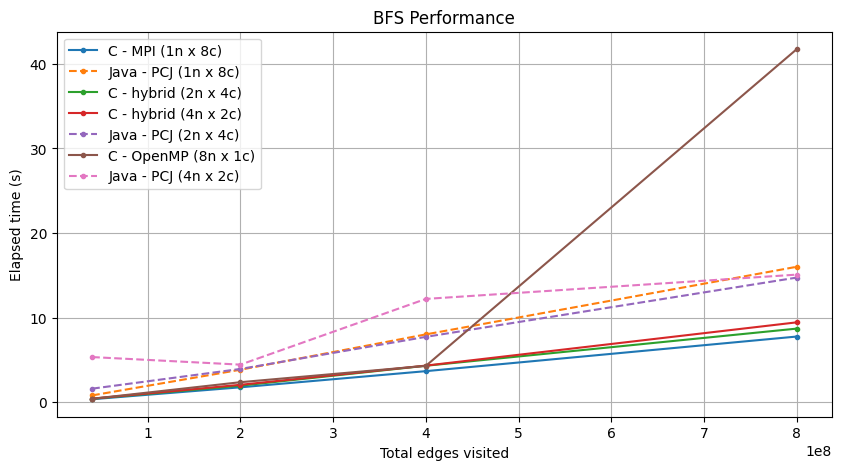

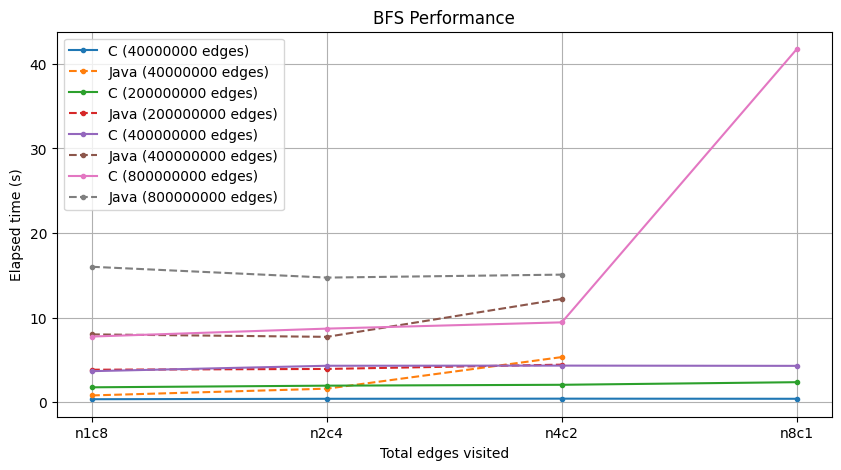

In [111]:
import matplotlib.pyplot as plt
import re
import os

results_path = "../mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("gr") != -1:
      if filename.startswith("c"):
        time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
        edges_pattern = re.compile(r"Total edges visited = (\d+)")
      else:
        time_pattern = re.compile(r"Time: ([\d.]+) s")
        edges_pattern = re.compile(r"Edges: (\d+)")

      text = f.read()

      times = time_pattern.findall(text)
      edges = edges_pattern.findall(text)


      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result


plot_1("BFS Performance", "Total edges visited", results)

plt.figure(figsize=(10, 5))

for n in list(results["c_n1c8"].keys()):
  x = list(filter(lambda k: k.startswith("c"), results.keys()))
  y = list(map(lambda k: results[k][n], x))

  xj = list(filter(lambda k: k.startswith("j"), results.keys()))
  yj = list(map(lambda k: results[k][n], xj))

  x = list(map(lambda x: x[2:], list(filter(lambda k: k.startswith("c"), results.keys()))))

  plt.plot(x, y, marker='.', label="C ("+str(n)+" edges)")
  plt.plot(x[:-1], yj, marker='.', label="Java ("+str(n)+" edges)", linestyle='--')

plt.xlabel("Total edges visited")
plt.ylabel("Elapsed time (s)")
plt.title("BFS Performance")
plt.legend()
plt.grid()

plt.show()

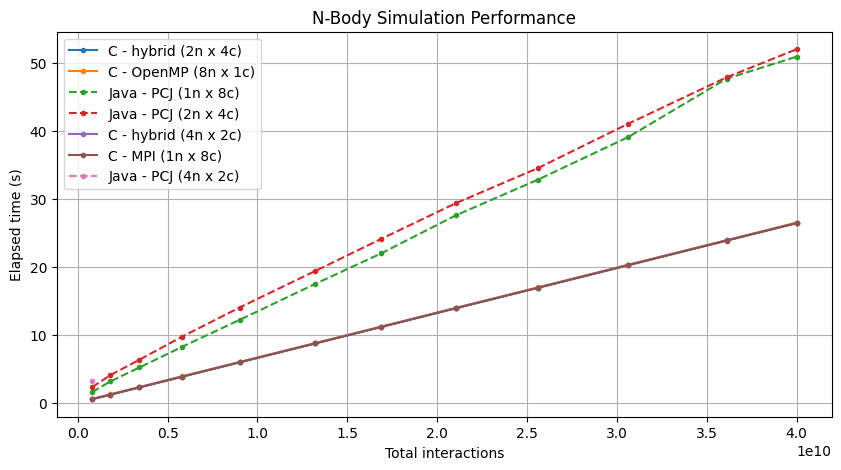

XJ ['j_n1c8', 'j_n2c4', 'j_n4c2']
RESULTS {'c_n2c4': {800000000: 0.535462, 1815000000: 1.209346, 3430000000: 2.276161, 5780000000: 3.836807, 9000000000: 5.959928, 13225000000: 8.758834, 16900000000: 11.186751, 21025000000: 13.92946, 25600000000: 16.941166, 30625000000: 20.266549, 36100000000: 23.914154, 40000000000: 26.46406}, 'c_n8c1': {800000000: 0.570238, 1815000000: 1.232802, 3430000000: 2.304756, 5780000000: 3.885262, 9000000000: 6.003087, 13225000000: 8.802219, 16900000000: 11.234121, 21025000000: 13.964121, 25600000000: 16.990053, 30625000000: 20.312052, 36100000000: 23.945489, 40000000000: 26.547101}, 'j_n1c8': {800000000: 1.58, 1815000000: 3.158, 3430000000: 5.204, 5780000000: 8.214, 9000000000: 12.211, 13225000000: 17.529, 16900000000: 22.028, 21025000000: 27.595, 25600000000: 32.861, 30625000000: 39.129, 36100000000: 47.727, 40000000000: 50.982}, 'j_n2c4': {800000000: 2.312, 1815000000: 4.078, 3430000000: 6.347, 5780000000: 9.707, 9000000000: 14.031, 13225000000: 19.427, 169

KeyError: 1815000000

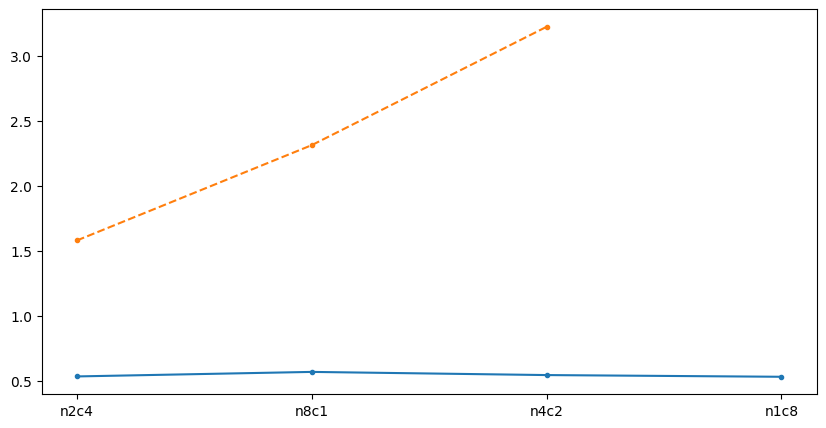

In [113]:
import matplotlib.pyplot as plt
import re
import os

results_path = "../mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("nb") != -1:
      text = f.read()
      if filename.startswith("c"):
        time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
        edges_pattern = re.compile(r"Total interactions = (\d+)")

        times = time_pattern.findall(text)
        edges = edges_pattern.findall(text)
      else:
        time_pattern = re.compile(r"Czas calkowity: ([\d.]+) s")
        edges_pattern = re.compile(r"Symulacja (\d+)")
        edges_pattern2 = re.compile(r"przez (\d+)")

        times = time_pattern.findall(text)
        bodies = edges_pattern.findall(text)
        iterations = edges_pattern2.findall(text)

        edges = [str(int(b) * int(b) * int(i)) for b, i in zip(bodies, iterations)]

      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result

plot_1("N-Body Simulation Performance", "Total interactions", results)

plt.figure(figsize=(10, 5))

for n in list(results["c_n1c8"].keys()):
  x = list(filter(lambda k: k.startswith("c"), results.keys()))
  y = list(map(lambda k: results[k][n], x))

  xj = list(filter(lambda k: k.startswith("j"), results.keys()))

  print("XJ", xj)
  print("RESULTS", results)

  yj = list(map(lambda k: results[k][n], xj))

  x = list(map(lambda x: x[2:], list(filter(lambda k: k.startswith("c"), results.keys()))))

  plt.plot(x, y, marker='.', label="C ("+str(n)+" edges)")
  plt.plot(x[:-1], yj, marker='.', label="Java ("+str(n)+" edges)", linestyle='--')

plt.xlabel("Total interactions")
plt.ylabel("Elapsed time (s)")
plt.title("BN-Body Simulation Performance")
plt.legend()
plt.grid()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for n in [40000000, 200000000, 400000000, 800000000]:
  x = list(filter(lambda k: k.startswith("c"), results.keys()))
  y = list(map(lambda k: results[k][n], x))

  xj = list(filter(lambda k: k.startswith("j"), results.keys()))
  yj = list(map(lambda k: results[k][n], xj))

  x = list(map(lambda x: x[2:], list(filter(lambda k: k.startswith("c"), results.keys()))))

  plt.plot(x, y, marker='.', label="C "+str(n))
  plt.plot(x[:-1], yj, marker='.', label="Java "+str(n), linestyle='--')

plt.xlabel("Total edges visited")
plt.ylabel("Elapsed time (s)")
plt.title("BFS Performance")
plt.legend()
plt.grid()

plt.show()

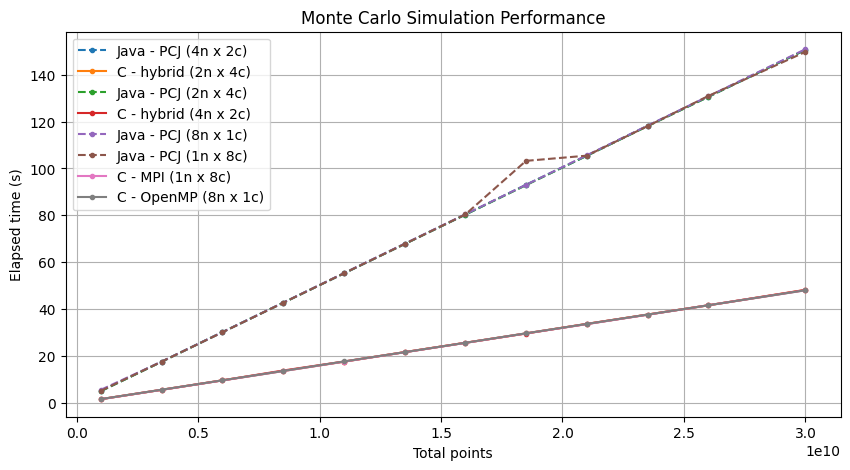

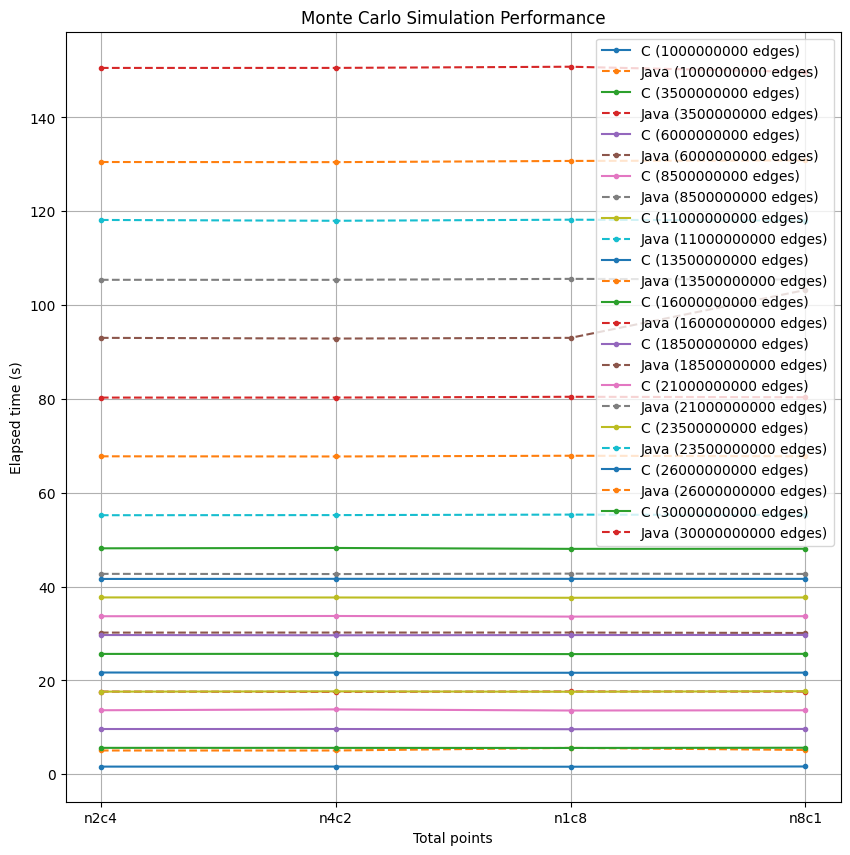

In [ ]:
import matplotlib.pyplot as plt
import re
import os

results_path = "../mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("mn") != -1 or filename.find("mc") != -1:
      text = f.read()
      time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
      edges_pattern = re.compile(r"Total points = (\d+)")

      times = time_pattern.findall(text)
      edges = edges_pattern.findall(text)

      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result

plot_1("Monte Carlo Simulation Performance", "Total points", results)

plt.figure(figsize=(10, 10))

for n in list(results["c_n1c8"].keys()):
  x = list(filter(lambda k: k.startswith("c"), results.keys()))
  y = list(map(lambda k: results[k][n], x))

  xj = list(filter(lambda k: k.startswith("j"), results.keys()))

  yj = list(map(lambda k: results[k][n], xj))

  x = list(map(lambda x: x[2:], list(filter(lambda k: k.startswith("c"), results.keys()))))

  plt.plot(x, y, marker='.', label="C ("+str(n)+" points)")
  plt.plot(x, yj, marker='.', label="Java ("+str(n)+" points)", linestyle='--')

plt.xlabel("Total points")
plt.ylabel("Elapsed time (s)")
plt.title("Monte Carlo Simulation Performance")
plt.legend()
plt.grid()

plt.show()